In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage
import ml_sandbox.dataset as mlds
from importlib import reload
reload(mlds)
get_dataset = mlds.get_dataset


# load galaxy dataset

In [5]:
from galaxy_datasets import gz_candels 


catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [6]:
catalog.head()

,smooth-or-featured-candels_smooth,smooth-or-featured-candels_features,smooth-or-featured-candels_artifact,how-rounded-candels_completely,how-rounded-candels_in-between,how-rounded-candels_cigar-shaped,clumpy-appearance-candels_yes,clumpy-appearance-candels_no,disk-edge-on-candels_yes,disk-edge-on-candels_no,edge-on-bulge-candels_yes,edge-on-bulge-candels_no,bar-candels_yes,bar-candels_no,has-spiral-arms-candels_yes,has-spiral-arms-candels_no,spiral-winding-candels_tight,spiral-winding-candels_medium,spiral-winding-candels_loose,spiral-arm-count-candels_1,spiral-arm-count-candels_2,spiral-arm-count-candels_3,spiral-arm-count-candels_4,spiral-arm-count-candels_5-plus,spiral-arm-count-candels_cant-tell,bulge-size-candels_none,bulge-size-candels_obvious,bulge-size-candels_dominant,merging-candels_merger,merging-candels_tidal-debris,merging-candels_both,merging-candels_neither,filename,ra,dec,file_loc
0,7.0,0.0,17.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,UDS_14439.jpg,34.481978,-5.195885,.tmp/images/UDS_14439.jpg
1,14.0,4.0,16.0,5.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,14.0,COS_89.jpg,150.088460,2.178708,.tmp/images/COS_89.jpg
2,5.0,5.0,8.0,2.0,3.0,0.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,10.0,GDS_14317.jpg,53.060933,-27.781595,.tmp/images/GDS_14317.jpg
3,17.0,7.0,12.0,4.0,13.0,0.0,2.0,5.0,0.0,5.0,0.0,0.0,0.0,5.0,1.0,4.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0,18.0,UDS_9017.jpg,34.350231,-5.225495,.tmp/images/UDS_9017.jpg
4,8.0,2.0,12.0,4.0,3.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,COS_7477.jpg,150.105650,2.269315,.tmp/images/COS_7477.jpg


In [7]:
cols = catalog.columns.to_numpy()

# initial testing

In [8]:
from ml_sandbox.dataset import load_image
import numpy as np
im = load_image(catalog['filename'][0], dir='.tmp/')


In [9]:
import torch

In [14]:
lcols = catalog.columns[catalog.columns.str.startswith('merging-candels')].to_list()

In [15]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
gzdataset = GalaxyDataset(
    catalog,
    label_cols=lcols,  
    # transform=ToTensor(),
    target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
    )

['merging-candels_merger',
 'merging-candels_tidal-debris',
 'merging-candels_both',
 'merging-candels_neither']

In [26]:
catalog.columns.str.startswith('merging-candels')


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True, False, False, False, False])

In [53]:
reload(mlds)
get_dataset = mlds.get_dataset
dataset_tr = get_dataset(catalog, label_key='merging-candels', size=1000, train=True, dir='.tmp/')

In [45]:
reload(mlds)
a = torch.tensor([0.1, 0.1, 0.1])
mlds.assign_label_by_max_vote(a)

tensor([1., 0., 0.])

In [54]:
for i in range(10):
    img, label = dataset_tr[i]
    print(f"{label=}")

label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])
label=tensor([1., 0., 0., 0.])
label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])
label=tensor([0., 0., 0., 1.])


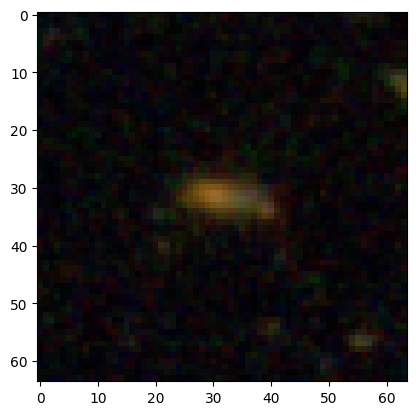

In [55]:
im, lab = dataset_tr[5]
plt.imshow(im.permute(1,2,0))

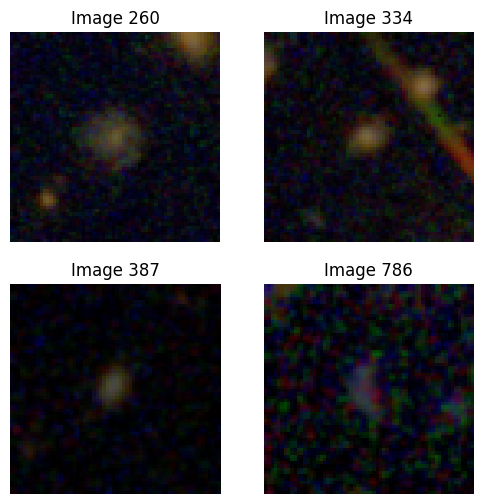

In [ ]:
from ml_sandbox.utils import show_sample_images
for i in range(3,4):
    show_sample_images(dataset_tr, num_images=i+1)

# training

In [57]:
catalog['merging-candels_merger'].max()+1

np.float64(59.0)

In [83]:
from ml_sandbox.models import SimpleCNNClassifier
import ml_sandbox.train_eval as mlte
reload(mlte)
train_cnn = mlte.train_cnn
test_cnn  = mlte.test_cnn
from ml_sandbox.dataset import get_dataloader
from sklearn.model_selection import train_test_split


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [78]:

label_key = 'merging-candels'
model = SimpleCNNClassifier(num_classes=np.sum(catalog.columns.str.startswith(label_key)), input_channels=3)
model=model.to(device)

train_cat, test_cat = train_test_split(catalog, test_size=0.2, random_state=42)

train_dataset = get_dataset(train_cat, label_key=label_key, 
                            size=train_cat.shape[0] // 5, train=True, dir='.tmp/')
test_dataset = get_dataset(test_cat, label_key=label_key, 
                           size=test_cat.shape[0] // 5, train=False, dir='.tmp/')

train_loader = get_dataloader(train_dataset, batch_size=8)
test_loader = get_dataloader(test_dataset, batch_size=8)


all_labels = []
for _, y in train_loader:
    all_labels.extend(y.tolist())

#mergers are heavily overrepresented, so we can compute class weights to balance the loss function
class_counts = torch.tensor([all_labels.count(c) for c in range(4)], dtype=torch.float)
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(class_counts)  # normalize
weights = weights.to(device)

from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss(weight=weights)

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping


In [59]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels.dim())
    break

/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
torch.Size([8, 3, 64, 64]) torch.Size([8, 4])
2


In [79]:
hist = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

do_cnn_training = True
if do_cnn_training:
    for i in range(5):
        train_loss, train_acc = train_cnn(train_loader, model, criterion, optimizer, device=device) 
        test_loss, test_acc = test_cnn(test_loader, model, criterion, device=device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['test_loss'].append(test_loss)
        hist['test_acc'].append(test_acc)
        print(f"Epoch: {i+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
loss: 1.425238  [    8/ 6342]
loss: 1.009865  [  808/ 6342]
loss: 0.944084  [ 1608/ 6342]
loss: 0.936886  [ 2408/ 6342]
loss: 0.798165  [ 3208/ 6342]
loss: 1.959087  [ 4008/ 6342]
loss: 0.987793  [ 4808/ 6342]
loss: 0.922243  [ 5608/ 6342]
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRing

In [81]:
model.eval()
i=0
for batch, (X, y) in enumerate(train_loader):
    X = X.to(device,non_blocking=True)
    y = y.to(device,non_blocking=True)

    pred = model(X)
    print(pred)
    print(pred.argmax(1))
    print(y)
    i +=1
    if i >= 5:
        break


/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
tensor([[ 0.4962, -0.7730, -1.9462,  1.2493],
        [ 0.5540, -0.7599, -1.2960,  0.6348],
        [ 0.7410, -1.0651, -1.8165,  0.8565],
        [ 0.2892, -0.5855, -1.6183,  1.1947],
        [ 0.3241, -0.6903, -2.0049,  1.4490],
        [ 0.6140, -0.8848, -1.7407,  0.9631],
        [ 0.4596, -0.7753, -2.0070,  1.3439],
        [ 0.43

In [74]:
from collections import Counter

all_labels = []
for _, y in train_loader:
    all_labels.extend(y.tolist())

print(Counter(all_labels))

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
Counter({3: 5447, 0: 766, 1: 89, 2: 40})


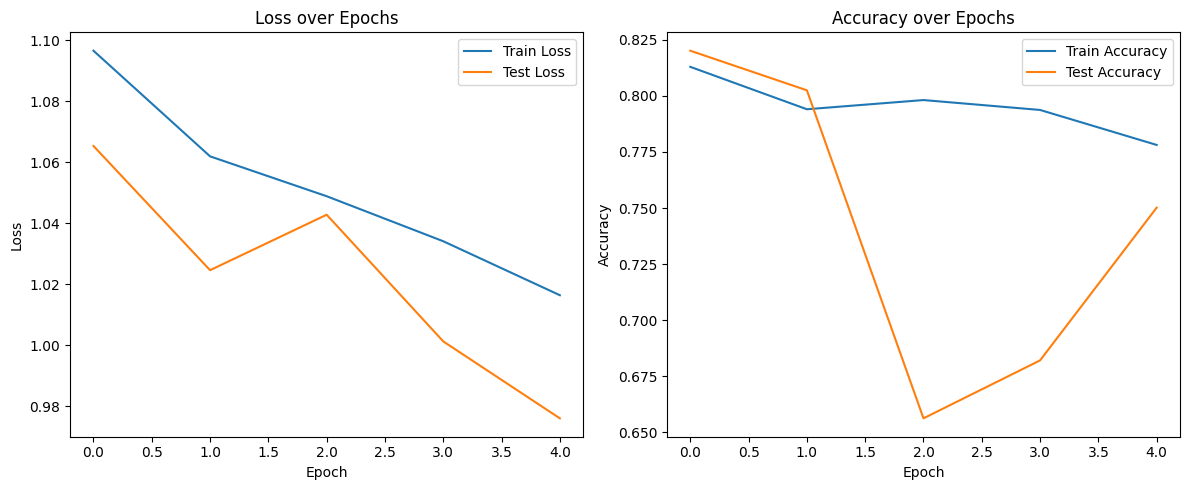

In [82]:
from ml_sandbox.train_eval import plot_training_history
plot_training_history(hist)

In [ ]:
from ml_sandbox.models import make_pca_rf_pipeline
model_skl = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
def test_convert_ds(dataset, batch_size=32, num_workers=None):
    """
    Convert a torch-style dataset to (X, y) using parallel workers.

    Uses a PyTorch `DataLoader` with `num_workers` to parallelize item loading
    and transforms. This avoids pickling the whole dataset object for
    multiprocessing and leverages DataLoader's worker pool.
    """
    import numpy as np
    from torch.utils.data import DataLoader
    import multiprocessing

    if num_workers is None:
        num_workers = min(4, multiprocessing.cpu_count())

    def collate_fn(batch):
        imgs = [b[0].cpu().numpy().ravel() for b in batch]
        labels = [int(b[1].item()) if hasattr(b[1], "item") else int(b[1]) for b in batch]
        return np.stack(imgs), np.array(labels, dtype=int)

    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, collate_fn=collate_fn)

    X_parts = []
    y_parts = []
    for Xb, yb in loader:
        X_parts.append(Xb)
        y_parts.append(yb)

    if len(X_parts) == 0:
        return np.empty((0,)), np.empty((0,))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


In [ ]:
# X_train, y_train = test_convert_ds(train_dataset)
# X_test, y_test = test_convert_ds(test_dataset)


In [ ]:
from ml_sandbox.dataset import convert_dataset_sklearn
X_train, y_train = convert_dataset_sklearn(train_dataset)
X_test, y_test = convert_dataset_sklearn(test_dataset)


In [ ]:
model_skl.fit(X_train, y_train)
test_accuracy = model_skl.score(X_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')


In [84]:
mlte.evaluate_cnn(test_loader, model, device)

/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
Confusion Matrix:
[[  79    0    0  102]
 [   7    0    0   13]
 [   8    0    0    4]
 [ 262    0    0 1110]]

Classification Report:
              precision    recall  f1-score   support

           0     0.2219    0.4365    0.2942       181
           1     0.0000    0.0000    0.0000        20
           2     0.0000    0.0000    0

/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri